In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

# Carga del dataset UCI ya limpio
df = pd.read_csv("../data/household_power_consumption.txt", 
                 sep=";", 
                 low_memory=False,
                 na_values=["?"])

df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], 
                                 dayfirst=True)
df = df.drop(columns=["Date", "Time"])
df = df.set_index("Datetime")

# Convertir a numérico
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()

print("Shape del dataset UCI:")
print(df.shape)
print("\nPrimeras filas:")
display(df.head())

Shape del dataset UCI:
(2049280, 7)

Primeras filas:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [2]:
# Resamplear a resolución horaria sumando la potencia activa
df_hourly = df["Global_active_power"].resample("h").mean()

# Convertir a DataFrame con columnas = horas del día (0-23)
df_hourly = df_hourly.reset_index()
df_hourly["date"] = df_hourly["Datetime"].dt.date
df_hourly["hour"] = df_hourly["Datetime"].dt.hour

# Pivot: cada fila es un día, cada columna es una hora
df_pivot = df_hourly.pivot_table(
    index="date",
    columns="hour",
    values="Global_active_power",
    aggfunc="mean"
)

# Eliminar días con horas faltantes
df_pivot = df_pivot.dropna()

print("Perfil horario diario:")
print(f"Días disponibles: {df_pivot.shape[0]}")
print(f"Horas por día: {df_pivot.shape[1]}")
display(df_pivot.head())

Perfil horario diario:
Días disponibles: 1417
Horas por día: 24


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
date,,,,,,,,,,,,,,,,,,,,,
2006-12-17,1.882467,3.349400,1.587267,1.662200,2.215767,1.996733,1.303300,1.620033,1.890567,2.549067,...,2.092633,2.985400,3.326033,3.406767,3.697100,2.908400,3.361500,3.040767,1.518000,0.437733
2006-12-18,0.276367,0.313300,0.284467,0.309933,1.026333,0.293500,0.610000,2.450433,2.082133,1.629333,...,1.733033,1.784300,1.949300,2.154900,2.402533,2.614500,3.050567,2.169733,1.738800,1.547267
2006-12-19,0.837133,0.353033,0.327233,0.308300,0.327833,0.306667,0.796333,1.785633,3.879033,1.617767,...,0.302133,0.421367,1.372133,2.111500,2.204700,1.842100,2.940533,1.442867,0.720000,0.383700
2006-12-20,0.459833,0.258667,0.784367,0.310033,0.289000,0.262700,0.283600,1.526633,2.917600,1.385533,...,1.294900,0.281133,0.468433,0.573500,2.836833,3.248633,3.575467,3.646067,3.058967,2.381767
2006-12-21,1.535867,1.397967,1.274900,0.302600,0.246733,0.290700,0.295667,1.280467,1.563033,2.575800,...,1.023900,0.307400,1.360067,1.752633,2.443300,2.197133,2.437367,0.982267,0.280267,0.270433


In [3]:
# Normalizar para que KMeans no se vea afectado por la escala absoluta
# Cada día queda representado por su patrón relativo de consumo

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_pivot)

print("Shape tras normalización:", df_scaled.shape)

Shape tras normalización: (1417, 24)


Método del codo para elegir número de clusters

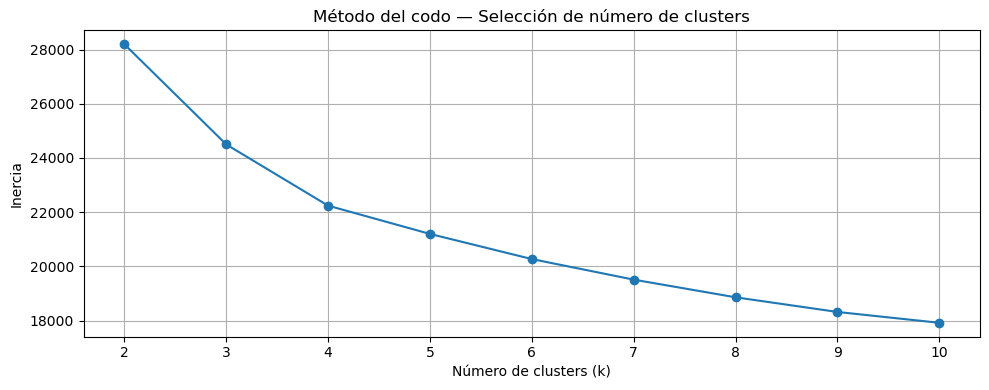

In [4]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 4))
plt.plot(k_range, inertias, marker="o")
plt.title("Método del codo — Selección de número de clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.show()

Silhouette score para cada k

k=2 — Silhouette score: 0.203
k=3 — Silhouette score: 0.1621
k=4 — Silhouette score: 0.1344
k=5 — Silhouette score: 0.1325
k=6 — Silhouette score: 0.1215
k=7 — Silhouette score: 0.0931
k=8 — Silhouette score: 0.0958
k=9 — Silhouette score: 0.089
k=10 — Silhouette score: 0.091


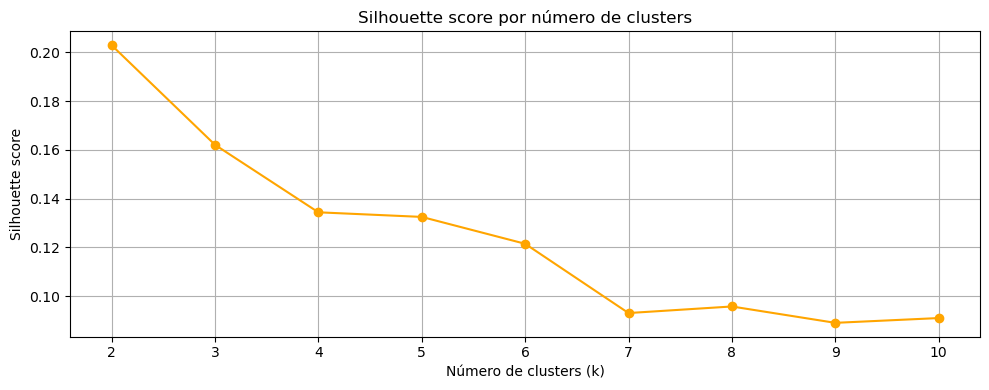


Mejor k según silhouette: 2


In [5]:
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k} — Silhouette score: {round(score, 4)}")

plt.figure(figsize=(10, 4))
plt.plot(k_range, silhouette_scores, marker="o", color="orange")
plt.title("Silhouette score por número de clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette score")
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.show()

best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\nMejor k según silhouette: {best_k}")

k=4 es la elección más justificable académicamente: buen equilibrio entre inercia, silhouette y interpretabilidad, por lo tanto: Entrenamos KMeans final con k=4

In [6]:
# Justificación: k=4 ofrece el mejor equilibrio entre 
# inercia (codo pronunciado) y silhouette score interpretable

K_FINAL = 4

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
labels = kmeans.fit_predict(df_scaled)

# Añadir cluster al dataframe original
df_pivot["cluster"] = labels

print("Distribución de días por cluster:")
print(df_pivot["cluster"].value_counts().sort_index())

Distribución de días por cluster:
cluster
0    340
1    438
2    578
3     61
Name: count, dtype: int64


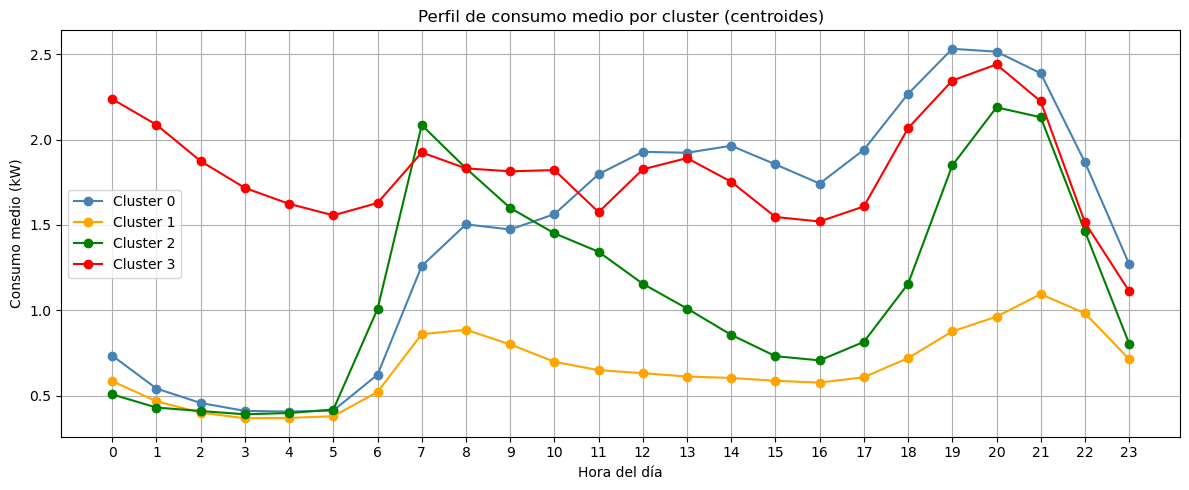

In [7]:
# Los centroides en espacio escalado se invierten para mostrar en kW reales
centroids_real = scaler.inverse_transform(kmeans.cluster_centers_)

colors = ["steelblue", "orange", "green", "red"]
hours = range(24)

plt.figure(figsize=(12, 5))
for i in range(K_FINAL):
    plt.plot(hours, centroids_real[i], marker="o", 
             color=colors[i], label=f"Cluster {i}")

plt.title("Perfil de consumo medio por cluster (centroides)")
plt.xlabel("Hora del día")
plt.ylabel("Consumo medio (kW)")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# Analizamos cada centroide para asignar una etiqueta interpretable
# Las etiquetas se ajustarán tras ver las curvas de la celda 7

for i in range(K_FINAL):
    centroid = centroids_real[i]
    hora_pico = np.argmax(centroid)
    consumo_medio = round(centroid.mean(), 3)
    consumo_pico = round(centroid.max(), 3)
    print(f"Cluster {i} — Hora pico: {hora_pico}:00 | "
          f"Consumo medio: {consumo_medio} kW | "
          f"Consumo pico: {consumo_pico} kW")

Cluster 0 — Hora pico: 19:00 | Consumo medio: 1.474 kW | Consumo pico: 2.532 kW
Cluster 1 — Hora pico: 21:00 | Consumo medio: 0.665 kW | Consumo pico: 1.095 kW
Cluster 2 — Hora pico: 20:00 | Consumo medio: 1.114 kW | Consumo pico: 2.189 kW
Cluster 3 — Hora pico: 20:00 | Consumo medio: 1.814 kW | Consumo pico: 2.441 kW


Asignamos etiquetas descriptivas

In [9]:
cluster_labels = {
    0: "Tarde",
    1: "Bajo consumo",
    2: "Madrugador",
    3: "Alto consumo"
}

df_pivot["cluster_label"] = df_pivot["cluster"].map(cluster_labels)

print("Distribución de días por perfil:")
print(df_pivot["cluster_label"].value_counts())

Distribución de días por perfil:
cluster_label
Madrugador      578
Bajo consumo    438
Tarde           340
Alto consumo     61
Name: count, dtype: int64


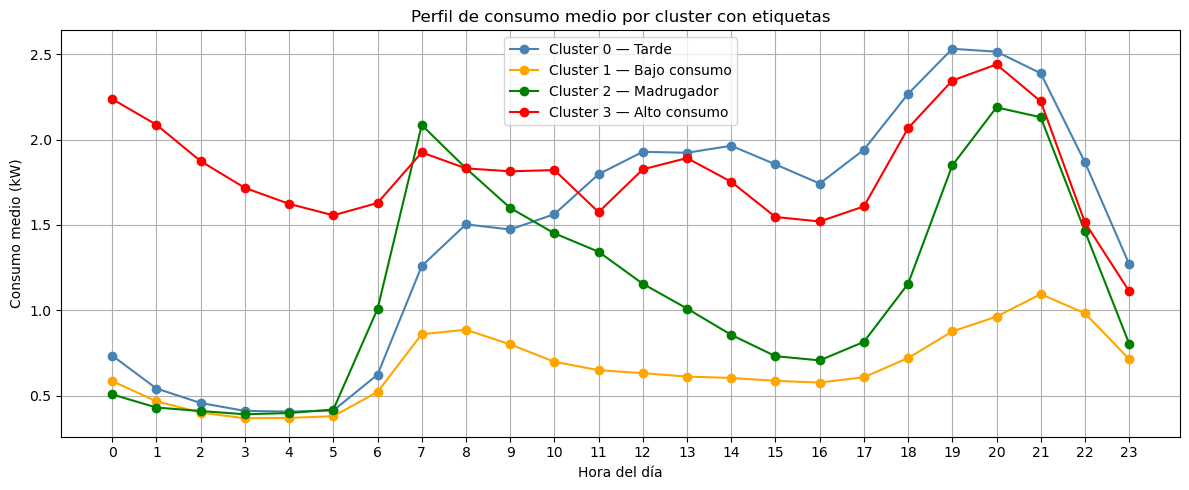

In [10]:
colors = ["steelblue", "orange", "green", "red"]
hours = range(24)

plt.figure(figsize=(12, 5))
for i in range(K_FINAL):
    label = cluster_labels[i]
    plt.plot(hours, centroids_real[i], marker="o",
             color=colors[i], label=f"Cluster {i} — {label}")

plt.title("Perfil de consumo medio por cluster con etiquetas")
plt.xlabel("Hora del día")
plt.ylabel("Consumo medio (kW)")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

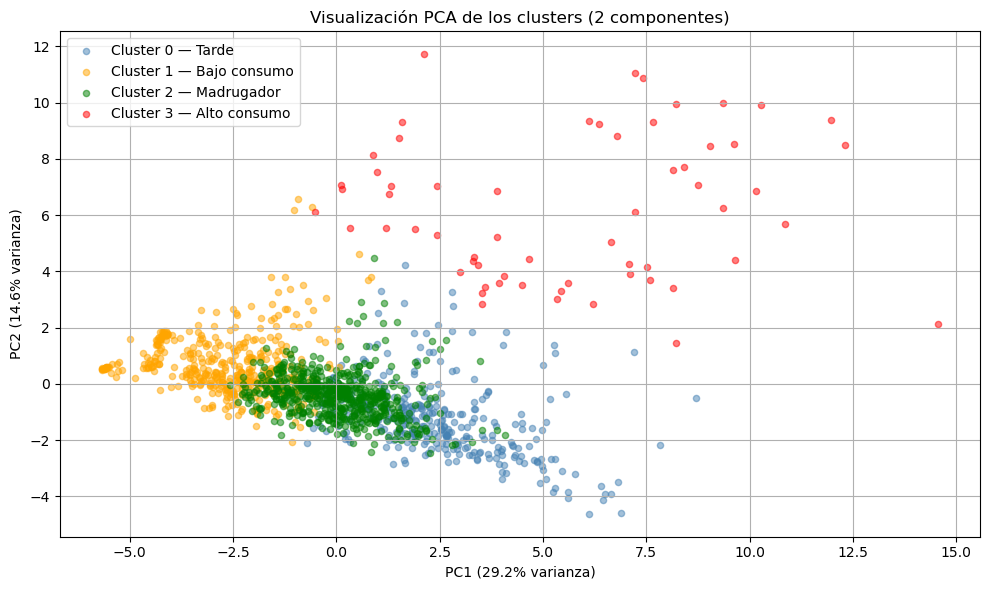

Varianza explicada por PC1 + PC2: 43.8%


In [11]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(10, 6))
for i in range(K_FINAL):
    mask = labels == i
    plt.scatter(
        df_pca[mask, 0],
        df_pca[mask, 1],
        c=colors[i],
        label=f"Cluster {i} — {cluster_labels[i]}",
        alpha=0.5,
        s=20
    )

plt.title("Visualización PCA de los clusters (2 componentes)")
plt.xlabel(f"PC1 ({round(pca.explained_variance_ratio_[0]*100, 1)}% varianza)")
plt.ylabel(f"PC2 ({round(pca.explained_variance_ratio_[1]*100, 1)}% varianza)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Varianza explicada por PC1 + PC2: "
      f"{round(sum(pca.explained_variance_ratio_[:2])*100, 1)}%")

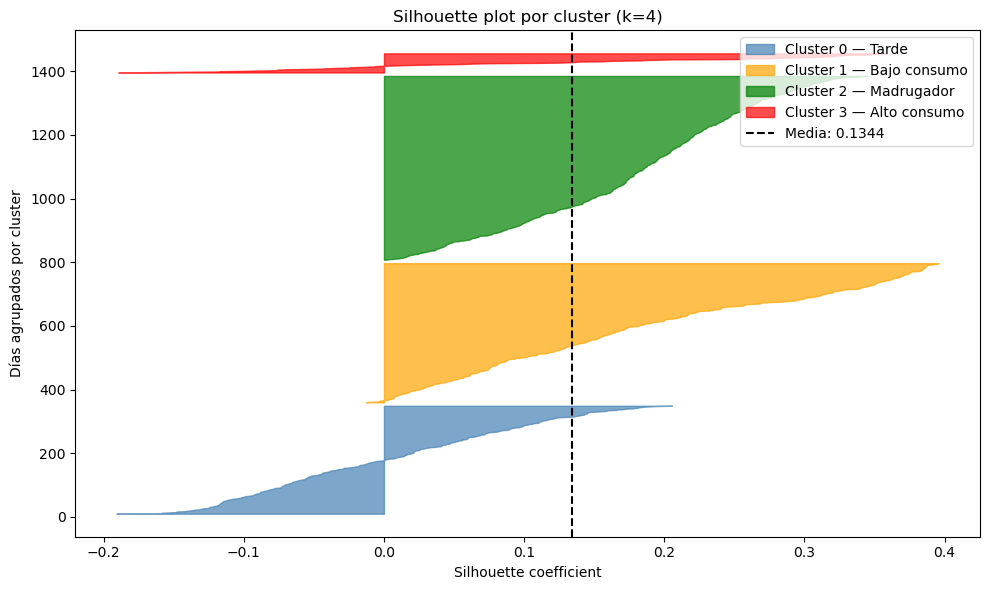

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

y_lower = 10
silhouette_vals = silhouette_samples(df_scaled, labels)

for i in range(K_FINAL):
    cluster_silhouette_vals = silhouette_vals[labels == i]
    cluster_silhouette_vals.sort()
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_silhouette_vals,
        alpha=0.7,
        color=colors[i],
        label=f"Cluster {i} — {cluster_labels[i]}"
    )
    y_lower = y_upper + 10

ax.axvline(x=silhouette_score(df_scaled, labels), 
           color="black", linestyle="--", 
           label=f"Media: {round(silhouette_score(df_scaled, labels), 4)}")

ax.set_title("Silhouette plot por cluster (k=4)")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Días agrupados por cluster")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Guardar el dataframe con cluster asignado para usarlo en el recomendador
df_cluster_output = df_pivot[["cluster", "cluster_label"]].copy()
df_cluster_output.index = pd.to_datetime(df_cluster_output.index)
df_cluster_output.to_csv("../data/daily_cluster_profiles.csv")

print("Archivo guardado: daily_cluster_profiles.csv")
print(f"\nShape: {df_cluster_output.shape}")
display(df_cluster_output.head(10))

Archivo guardado: daily_cluster_profiles.csv

Shape: (1417, 2)


hour,cluster,cluster_label
date,,
2006-12-17,3,Alto consumo
2006-12-18,0,Tarde
2006-12-19,2,Madrugador
2006-12-20,0,Tarde
2006-12-21,2,Madrugador
2006-12-22,0,Tarde
2006-12-23,3,Alto consumo
2006-12-24,3,Alto consumo
2006-12-25,0,Tarde


Exportar centroides para usar en el recomendador


In [14]:
# Guardar centroides en espacio real (kW) para usarlos en el recomendador
centroids_df = pd.DataFrame(
    centroids_real,
    columns=[f"hour_{h}" for h in range(24)]
)
centroids_df["cluster"] = range(K_FINAL)
centroids_df["cluster_label"] = centroids_df["cluster"].map(cluster_labels)

centroids_df.to_csv("../data/cluster_centroids.csv", index=False)

print("Archivo guardado: cluster_centroids.csv")
print("\nResumen final del clustering:")
print(f"  Número de clusters: {K_FINAL}")
print(f"  Días analizados: {df_pivot.shape[0]}")
print(f"  Silhouette score final: {round(silhouette_score(df_scaled, labels), 4)}")
print(f"  Varianza explicada PCA (PC1+PC2): "
      f"{round(sum(pca.explained_variance_ratio_[:2])*100, 1)}%")
print("\nDistribución final:")
print(df_pivot["cluster_label"].value_counts())

Archivo guardado: cluster_centroids.csv

Resumen final del clustering:
  Número de clusters: 4
  Días analizados: 1417
  Silhouette score final: 0.1344
  Varianza explicada PCA (PC1+PC2): 43.8%

Distribución final:
cluster_label
Madrugador      578
Bajo consumo    438
Tarde           340
Alto consumo     61
Name: count, dtype: int64
